In [41]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.metrics import classification_report, make_scorer, accuracy_score, f1_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [28]:
import warnings

warnings.filterwarnings('ignore')

In [29]:
full_data = pd.read_csv('../data/processed/features_engineered.csv')

targets = ['Sleep_Quality_Num', 'Stress_Level_Num', 'Health_Issues_Num']

# Drop targets to get features
X = full_data.drop(columns=targets + ['Cluster', 'UMAP1', 'UMAP2'], errors='ignore')
Y = full_data[targets]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [31]:
preprocessor = joblib.load('../models/preprocessor.joblib')

In [32]:
def run_cross_validation(X_data, y_data, target_name):
    print(f"\n--- Running 5-Fold CV for: {target_name} ---")
    
    # We use StratifiedKFold to keep the balance of classes consistent
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    
    # We transform X through the preprocessor before CV
    X_processed = preprocessor.transform(X_data)
    
    cv_results = cross_validate(
        model, X_processed, y_data, 
        cv=skf, 
        scoring=['accuracy', 'f1_macro'],
        return_train_score=False
    )
    
    print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std() * 2:.4f})")
    print(f"Mean F1 Macro: {cv_results['test_f1_macro'].mean():.4f}")
    return cv_results

In [33]:
cv_summary = {}
for target in targets:
    cv_summary[target] = run_cross_validation(X_train, y_train[target], target)


--- Running 5-Fold CV for: Sleep_Quality_Num ---
Mean Accuracy: 0.9725 (+/- 0.0102)
Mean F1 Macro: 0.9688

--- Running 5-Fold CV for: Stress_Level_Num ---
Mean Accuracy: 0.9799 (+/- 0.0067)
Mean F1 Macro: 0.9702

--- Running 5-Fold CV for: Health_Issues_Num ---
Mean Accuracy: 0.9846 (+/- 0.0038)
Mean F1 Macro: 0.9676


In [34]:
def tune_and_calibrate(X_data, y_data, target_name):
    print(f"\n--- Tuning & Calibrating: {target_name} ---")
    
    X_processed = preprocessor.transform(X_data)
    
    # Define the Search Space
    param_dist = {
        'num_leaves': [20, 31, 50, 70],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 500],
        'max_depth': [-1, 10, 20],
        'subsample': [0.8, 0.9, 1.0]
    }
    
    lgbm = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    
    # Randomized Search
    search = RandomizedSearchCV(
        lgbm, param_distributions=param_dist, 
        n_iter=10, cv=3, scoring='f1_macro', random_state=42
    )
    search.fit(X_processed, y_data)
    
    best_model = search.best_estimator_
    print(f"Best Params: {search.best_params_}")
    
    # --- Step 4: Calibration ---
    # This makes the probability outputs more reliable for health predictions
    calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
    calibrated_model.fit(X_processed, y_data)
    
    # Save the Refined Model
    os.makedirs('../models/refined', exist_ok=True)
    save_path = f'../models/refined/lgbm_refined_{target_name}.joblib'
    joblib.dump(calibrated_model, save_path)
    print(f"Refined model saved to: {save_path}")
    
    return calibrated_model

In [35]:
refined_models = {}
for target in targets:
    refined_models[target] = tune_and_calibrate(X_train, y_train[target], target)


--- Tuning & Calibrating: Sleep_Quality_Num ---
Best Params: {'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
Refined model saved to: ../models/refined/lgbm_refined_Sleep_Quality_Num.joblib

--- Tuning & Calibrating: Stress_Level_Num ---
Best Params: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05}
Refined model saved to: ../models/refined/lgbm_refined_Stress_Level_Num.joblib

--- Tuning & Calibrating: Health_Issues_Num ---
Best Params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1}
Refined model saved to: ../models/refined/lgbm_refined_Health_Issues_Num.joblib


In [38]:
def plot_all_calibrations(models_dict, X_data, y_true_df):
    plt.figure(figsize=(10, 7))
    X_proc = preprocessor.transform(X_data)
    
    # Standard colors for professional look
    colors = ['#636efa', '#ef553b', '#00cc96']
    
    for (target, model), color in zip(models_dict.items(), colors):
        # Get probabilities for the positive class
        # (Assuming binary-like behavior for calibration check)
        probs = model.predict_proba(X_proc)[:, 1] 
        
        # We simplify the true labels to binary (0 vs >0) for the curve check
        y_true_binary = (y_true_df[target] > 0).astype(int)
        
        fop, mpv = calibration_curve(y_true_binary, probs, n_bins=5)
        plt.plot(mpv, fop, marker='s', label=f'{target}', color=color)

    plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    plt.title("Reliability Diagrams: Refined Models (v1.1.0)")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

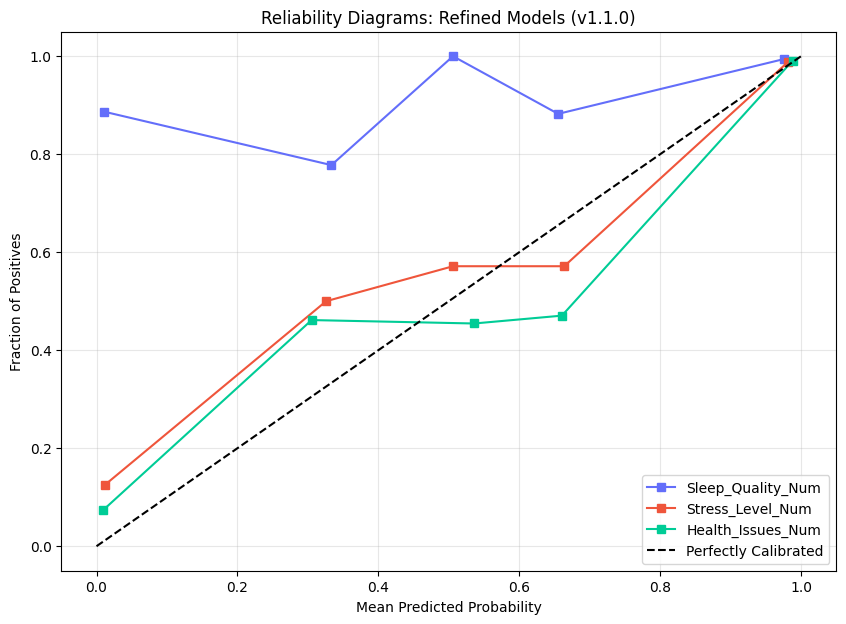

In [39]:
plot_all_calibrations(refined_models, X_test, y_test)

In [42]:
print("--- FINAL REFINED MODEL EVALUATION (Test Set) ---")
for target, model in refined_models.items():
    X_test_proc = preprocessor.transform(X_test)
    y_pred = model.predict(X_test_proc)
    
    acc = accuracy_score(y_test[target], y_pred)
    f1 = f1_score(y_test[target], y_pred, average='macro')
    
    print(f"Target: {target}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test F1 Macro: {f1:.4f}\n")

--- FINAL REFINED MODEL EVALUATION (Test Set) ---
Target: Sleep_Quality_Num
  Test Accuracy: 0.9655
  Test F1 Macro: 0.9593

Target: Stress_Level_Num
  Test Accuracy: 0.9790
  Test F1 Macro: 0.9673

Target: Health_Issues_Num
  Test Accuracy: 0.9830
  Test F1 Macro: 0.9586

